# What forgetting costs, geometrically

## 1. The question

Continual learning studies networks whose training data arrives as a sequence
rather than all at once. The sequential condition imposes a constraint that
stationary training does not. A network optimises for the task in front of it
while being graded, implicitly, on tasks it no longer sees.

The field measures the consequence two ways. Behavioural measures report the
accuracy lost on a past task. Representational measures report how far the
internal representation moved, using a similarity index such as CKA.

Both stop short of identifying what changed. Accuracy is a readout of the
representation through a classifier, so it reports a consequence rather than a
cause. A similarity index collapses every kind of geometric change into one
scalar, so two networks with identical drift can have lost a task for different
reasons.

This project comes out of a previous workshop paper
(https://arxiv.org/abs/2606.17889), which found that modularity's benefit in
continual learning is conditional on feature-learning strength. That result was
established with similarity indices. They establish that the geometry mattered
and leave open what about it changed.

Here the architecture is set aside and the geometry is measured directly. The
instrument is manifold capacity, decomposed into three geometric factors. The
decomposition is an identity, so a change in capacity attributes to those three
with nothing left over. The question becomes which property a representation
spends when a past task stops being readable.

What follows. The stream and the data (§2–4). The measurement, what it
decomposes into, and the distinction that only exists in a sequence (§5–7).
Four findings (§8). The four constraints that bound them (§9).


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linprog
from scipy.spatial.distance import pdist

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
rng = np.random.default_rng(0)


def find_repo():
    here = Path.cwd().resolve()
    candidates = [
        here,
        here.parent,
        here / "continual_geometry",
        here.parent / "continual_geometry",
    ]
    if here.name == "notebooks":
        candidates.insert(0, here.parent)
    for cand in candidates:
        if (cand / "figures").is_dir() and (cand / "results").is_dir():
            return cand
    raise FileNotFoundError(
        "could not find a continual_geometry tree with figures/ and results/"
    )


REPO = find_repo()
print("repo:", REPO)


/home/kat/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-3mrlbqjs because there was an issue with the default path (/home/kat/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


repo: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/continual_geometry


## 2. What was run

A **task** is one balanced split. An **arm** is one trained network on one stream.
The sequence those arms see is specified below. Every cell is filled by
construction.

| property | in these runs |
|---|---|
| **similarity** | two axes, set independently. Readout similarity is Hamming agreement between splits. Feature similarity is centre correlation between arrangements. |
| **order** | fixed, one pass, no recurrence |
| **scope** | one split over sixteen manifolds, uniform across tasks |
| **change** | abrupt at every boundary |
| **access** | no task identity, no boundary signal, no reset |
| **agent** | one hidden layer, ReLU, 300 units, shared scalar readout, full-batch GD on MSE |

The experimental knob is **feature-learning strength** $\gamma_0$, from 0.03 to 10.
It sets the output scale and the learning rate together, and interpolates between
the kernel limit and feature learning. The two ends are conventionally called
lazy and rich. $\gamma_0$ co-varies with optimisation dynamics, which is why a
low-rank control at fixed $\gamma_0$ is the next experiment.

The parameterisation is from Graldi et al. (2025), who use $\gamma_0$ to study
feature-learning strength in continual learning across model scales. Their
infinite-width arm is the same model class used here: a two-layer ReLU network
trained by full-batch gradient descent on MSE, with the readout initialised to
zero. Their behavioural optimum $\gamma_0^* \approx 0.1$ comes from their ResNet
experiments, so comparing optima across the two studies compares architectures.

Eight independent arrangement draws sit behind each reported cell. Architecture
is held fixed so that measured geometric change is not confounded by routing,
replay, or a task head.


## 3. Sixteen clouds

The inputs are sixteen point clouds, drawn once and then held fixed. Each cloud
is a $D$-dimensional sphere of radius $R$ in a high-dimensional ambient space.
The generator is Chou et al. (ICML 2025), App. D.1.1
(https://arxiv.org/abs/2503.18114).

Size and position are independent knobs. The capacity identity later attributes
a change in forgetting to those same properties. How large each cloud is. How
many directions it spreads along. How the clouds sit relative to a split. If
the generator mixed size into position, that attribution would be unreadable.

The next cell prints the mean within-cloud radius and the mean gap between
centres. Their ratio is that split, made visible.


arrangement: (16, 20, 60)   (manifolds, points, dimensions)
mean within-manifold radius : 0.966
mean between-centre distance: 1.416
ratio                        : 0.682


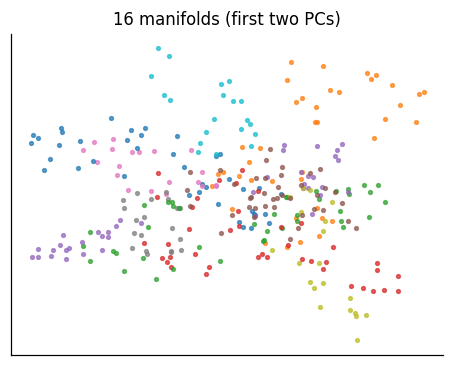

In [2]:
def make_arrangement(P=16, M=20, d=60, D=4, R=1.0, eps=1e-2, rho_C=0.0, rng=None):
    '''P point-cloud manifolds. Chou et al. ICML 2025, App. D.1.1.

    Each manifold is centre + R * (unit-norm spread over D axes) + noise.
    The spread is normalised to unit norm before scaling by R, which is what
    makes D and R independent knobs.
    rho_C > 0 correlates centres by left-multiplying with the Cholesky factor
    of the AR(1) matrix C_ij = rho_C^{|i-j|}.
    (Smaller P/M/d than the trained runs, so the demo is fast.)
    '''
    rng = np.random.default_rng(0) if rng is None else rng
    centres = rng.normal(0, 1 / np.sqrt(d), (P, d))
    if rho_C > 0.0:
        idx = np.arange(P)
        cov = np.power(rho_C, np.abs(idx[:, None] - idx[None, :]))
        centres = np.linalg.cholesky(cov) @ centres
    out = np.empty((P, M, d))
    for i in range(P):
        axes = rng.normal(0, 1 / np.sqrt(d), (D, d))
        s = rng.normal(0, 1, (M, D))
        pre = s @ axes
        pre /= np.linalg.norm(pre, axis=1, keepdims=True)
        noise = rng.normal(0, 1 / np.sqrt(d), (M, d))
        out[i] = centres[i] + R * pre + eps * noise
    return out


def pca2(mans):
    Xall = mans.reshape(-1, mans.shape[-1])
    Xc = Xall - Xall.mean(0)
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    return (Xc @ Vt[:2].T).reshape(mans.shape[0], mans.shape[1], 2)


mans = make_arrangement(rng=np.random.default_rng(1))
print("arrangement:", mans.shape, "  (manifolds, points, dimensions)")

centres = mans.mean(axis=1)
radius = np.linalg.norm(mans - centres[:, None], axis=2).mean(axis=1)
gaps = pdist(centres)
print(f"mean within-manifold radius : {radius.mean():.3f}")
print(f"mean between-centre distance: {gaps.mean():.3f}")
print(f"ratio                        : {radius.mean() / gaps.mean():.3f}")

proj = pca2(mans)
fig, ax = plt.subplots(figsize=(4.2, 3.4))
for i in range(mans.shape[0]):
    ax.scatter(*proj[i].T, s=6, alpha=0.7)
ax.set_title("16 manifolds (first two PCs)")
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()


## 4. A task is a way of splitting them

The sixteen clouds never change. A task is which eight are labelled $+1$ and
which eight $-1$. The network is trained to output that sign. Sixteen such
splits run in sequence.

Because the clouds are fixed, the inputs are identical and only the required
answer changes. Any interference is therefore caused by the rule, not by seeing
different data.

Two independent similarity axes.

- **readout similarity** — Hamming agreement between the $\pm 1$ vectors of two
  splits. A split and its complement are the same task.
- **feature similarity** — mean pairwise cosine of the centres. This is the
  signed $\rho_c$ convention. One number for how aligned the cloud positions are.

The two axes are Hiratani's (2024). He derives their interaction analytically in
a linear teacher-student model with latent structure, and shows that high
feature similarity combined with low readout similarity damages both transfer
and retention, while the reverse combination is comparatively benign. His model
has no manifold structure, so the geometry those axes act on cannot be measured
in it. We set the same two axes and measure what they do to centre geometry.


task 0: [-1 -1 -1  1 -1  1 -1 -1  1  1  1  1 -1  1  1 -1]
  Hamming  2 -> readout similarity 0.75   [ 1 -1 -1  1 -1  1 -1 -1  1  1  1 -1 -1  1  1 -1]
  Hamming  8 -> readout similarity 0.00   [-1  1 -1 -1  1  1 -1  1 -1  1  1  1 -1 -1 -1  1]
  Hamming 16 -> readout similarity 1.00   [ 1  1  1 -1  1 -1  1  1 -1 -1 -1 -1  1 -1 -1  1]


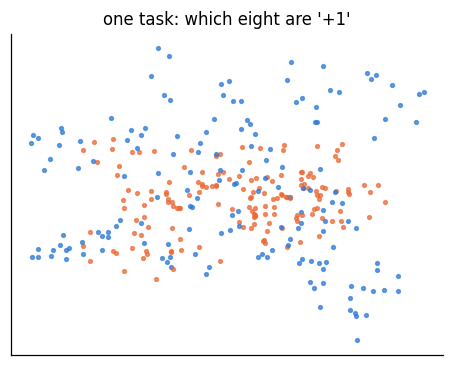

In [3]:
def balanced_dichotomy(P, rng):
    y = np.array([1] * (P // 2) + [-1] * (P // 2))
    rng.shuffle(y)
    return y


def readout_similarity(y1, y2):
    '''Sign-symmetric. A split and its complement are the same task.'''
    return abs(2 * np.mean(y1 == y2) - 1)


def at_hamming(y, h, rng):
    '''A new split at Hamming distance h. Swap h/2 of each side.'''
    y = y.copy()
    pos, neg = np.where(y > 0)[0], np.where(y < 0)[0]
    k = h // 2
    y[rng.choice(pos, k, replace=False)] = -1
    y[rng.choice(neg, k, replace=False)] = +1
    return y


r = np.random.default_rng(3)
y0 = balanced_dichotomy(16, r)
print("task 0:", y0)
for h in [2, 8, 16]:
    y = at_hamming(y0, h, r)
    print(f"  Hamming {h:2d} -> readout similarity {readout_similarity(y0, y):.2f}   {y}")

proj = pca2(mans)
fig, ax = plt.subplots(figsize=(4.2, 3.4))
for i in range(mans.shape[0]):
    ax.scatter(*proj[i].T, s=6, alpha=0.7,
               color="#2a78d6" if y0[i] > 0 else "#eb6834")
ax.set_title("one task: which eight are '+1'")
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()


Hamming 2 means two labels differ. Agreement is then $14/16$, and readout
similarity is $|2 \times 14/16 - 1| = 0.75$. That is a nearby rule on the same
clouds. Hamming 16 is the complement, which this measure treats as the same
task, so similarity is 1. Feature similarity is a property of the clouds, not
of the labels, and is set separately.


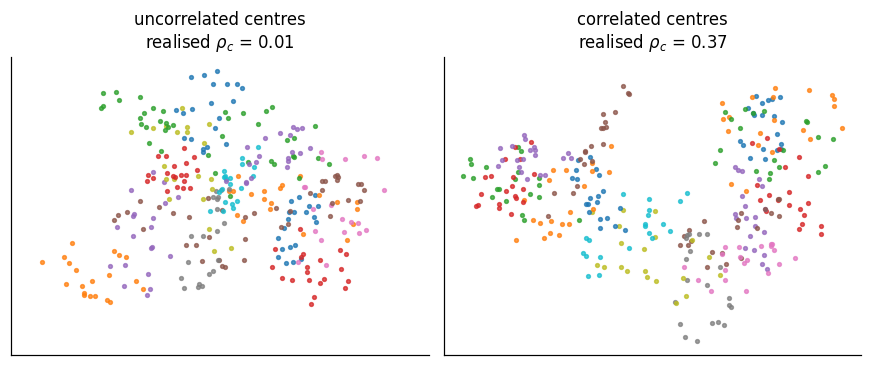

In [4]:
def centre_corr(mans):
    '''Mean pairwise cosine of centres. The signed rho_c convention.'''
    S0 = mans.mean(axis=1)
    G = S0 @ S0.T
    norms = np.sqrt(np.diag(G))
    C = G / np.outer(norms, norms)
    off = ~np.eye(len(S0), dtype=bool)
    return float(C[off].mean())


fig, ax = plt.subplots(1, 2, figsize=(8, 3.4), sharex=True, sharey=True)
for a, rho, title in zip(
    ax,
    (0.0, 0.8),
    ("uncorrelated centres", "correlated centres"),
):
    m = make_arrangement(rho_C=rho, rng=np.random.default_rng(7))
    proj = pca2(m)
    for i in range(m.shape[0]):
        a.scatter(*proj[i].T, s=6, alpha=0.75)
    a.set_title(f"{title}\nrealised $\\rho_c$ = {centre_corr(m):.2f}")
    a.set_xticks([])
    a.set_yticks([])
plt.tight_layout()
plt.show()


The generator's $\rho_C$ is the requested centre correlation. The printed
$\rho_c$ is the value realised on the draw. Left, centres point in unrelated
directions. Right, they are aligned, so the clouds sit in a tighter bundle.
The trained streams sit at the four corners of the two axes. High or low
readout similarity, crossed with high or low feature similarity. Those corners
are named S-HH, S-HL, S-LH, S-LL.


## 5. What capacity is

Given a set of point clouds, **how many different two-way splits could a linear
readout still separate?** High capacity means the clouds sit in an arrangement
that supports many possible questions.

Two representations can move the same distance in CKA and lose a task for
different geometric reasons.

Manifold capacity is a result in the statistical physics of perceptrons. Chung,
Lee and Sompolinsky (2018) derive it for manifolds of arbitrary geometry and
identify anchor points as the object linking geometry to separability. Cohen et
al. (2020) apply it along the layers of trained deep networks and find capacity
improving through a coordinated reduction of radius, dimension and
inter-manifold correlation. The measure is not defined for this project. Its use
along a sequence is.

Operationally, squeeze the representation into fewer dimensions by random
projection. At some point linear separation becomes impossible. The dimension
where separability is at a coin-flip is $N_{\text{crit}}$, and capacity is
$\alpha = P / N_{\text{crit}}$.


In [5]:
def separable(X, labels):
    '''Is there a w with labels_i * <w, x_i> >= 1 for all i? An LP feasibility test.'''
    A_ub = -(labels[:, None] * X)
    b_ub = -np.ones(len(X))
    res = linprog(
        np.zeros(X.shape[1]), A_ub=A_ub, b_ub=b_ub,
        bounds=[(None, None)] * X.shape[1], method="highs",
    )
    return res.status == 0


def frac_separable(mans, n, rng, n_dich=6, n_proj=3, y=None):
    P, M, d = mans.shape
    X = mans.reshape(P * M, d)
    hits = tot = 0
    n_loop = 1 if y is not None else n_dich
    for _ in range(n_loop):
        lab_p = y if y is not None else balanced_dichotomy(P, rng)
        lab = np.repeat(lab_p, M)
        for _ in range(n_proj):
            W = rng.normal(size=(d, n)) / np.sqrt(d)
            hits += int(separable(X @ W, lab))
            tot += 1
    return hits / tot


def capacity(mans, rng, **kw):
    '''alpha = P / N_crit, by bisection on the projection dimension.'''
    P, M, d = mans.shape
    lo, hi = 1, d
    while lo < hi:
        mid = (lo + hi) // 2
        if frac_separable(mans, mid, rng, **kw) >= 0.5:
            hi = mid
        else:
            lo = mid + 1
    return P / lo, lo


In [6]:
rows = []
for R in [0.5, 1.0, 2.0]:
    a, nc = capacity(make_arrangement(R=R, rng=np.random.default_rng(1)), rng)
    rows.append(("radius", R, a, nc))
for D in [2, 4, 8]:
    a, nc = capacity(make_arrangement(D=D, rng=np.random.default_rng(1)), rng)
    rows.append(("dimension", D, a, nc))

print(f"{'knob':<10}{'value':>7}{'capacity':>11}{'N_crit':>8}")
for k, v, a, nc in rows:
    print(f"{k:<10}{v:>7g}{a:>11.3f}{nc:>8}")

m = make_arrangement(rng=np.random.default_rng(1))
split_rng = np.random.default_rng(11)
print()
print(f"{'split':<16}{'capacity':>11}{'N_crit':>8}  labels")
ys = {}
for name in ("split A", "split B"):
    y = balanced_dichotomy(16, split_rng)
    ys[name] = y
    a, nc = capacity(m, rng, y=y)
    print(f"{name:<16}{a:>11.3f}{nc:>8}  {y}")
print("readout similarity A vs B:",
      f"{readout_similarity(ys['split A'], ys['split B']):.2f}")


knob        value   capacity  N_crit
radius        0.5      0.800      20
radius          1      0.471      34
radius          2      0.333      48
dimension       2      0.640      25
dimension       4      0.500      32
dimension       8      0.410      39

split              capacity  N_crit  labels


split A               0.410      39  [ 1 -1 -1 -1  1 -1  1  1 -1  1 -1  1 -1  1  1 -1]
split B               0.533      30  [-1 -1  1 -1  1  1 -1 -1  1 -1  1  1 -1 -1  1  1]
readout similarity A vs B: 0.25


Fatter clouds and higher-dimensional clouds both raise $N_{\text{crit}}$, so
capacity falls. Those are the generator's two size knobs, recovered by the
estimator.

Split A and split B are two different balanced questions on the same clouds.
Their labels differ, their readout similarity is below 1, and their
$N_{\text{crit}}$ values differ because some splits cut between well-separated
groups and others cut through the arrangement. Capacity is a property of a
representation together with a question, not of the representation alone.


## 6. The decomposition

Chou et al. show that capacity equals a product of three geometric factors.
The equality is an identity, not a fit. Once the three factors are computed,
their product *is* $\alpha$. There is no leftover term to model.

$$
\alpha \;=\; \Psi_{\text{eff}} \cdot \frac{1 + R_{\text{eff}}^{-2}}{D_{\text{eff}}}
$$

- $D_{\text{eff}}$ — how many independent directions each cloud spreads along
- $R_{\text{eff}}$ — how large each cloud is relative to the distance between clouds
- $\Psi_{\text{eff}}$ — how efficiently that spread is arranged for the split being asked

A change in $\alpha$ therefore splits in log space with nothing left over.

$$
\Delta\log\alpha
\;=\;
\Delta\log\Psi_{\text{eff}}
\,+\,
\Delta\log(1+R_{\text{eff}}^{-2})
\,-\,
\Delta\log D_{\text{eff}}
$$

Those three terms are the **utility**, **radius**, and **dimension** channels.
The identity says which of those three properties moved. A similarity index
such as CKA or PWCCA reports only that the representation moved.

The cell below loads one arm and checks the identity on two stored
**geometry points**. A geometry point is one capacity measurement, stored at
one task boundary, for one past task, on one **module**. A module is one of two
identically configured halves of the network. We measure them separately. The
past task here is the first split in the stream.


In [7]:
def load_one_arm():
    candidates = [
        REPO / "results/nottuned/gamma-10__a-0__cond-S-HL__stream-10000__seed-0__pop-reserved.json",
        REPO / "results/small_n_grid/N16__gamma-10__a-0__cond-S-HL__stream-0__seed-0.json",
    ]
    for path in candidates:
        if path.exists():
            rec = json.loads(path.read_text())
            rec["_path"] = str(path.relative_to(REPO))
            return rec
    raise FileNotFoundError("no trained arm with geometry records found")


def pick_geom(arm, *, module, boundary, task, ensemble):
    hits = [
        g for g in arm["geometry"]
        if g["module"] == module
        and g["boundary"] == boundary
        and g["task"] == task
        and g["ensemble"] == ensemble
    ]
    if len(hits) != 1:
        raise ValueError(f"expected one geometry record, got {len(hits)}")
    return hits[0]


def alpha_from_identity(g):
    return g["Psi_eff"] * (1.0 + g["R_eff"] ** -2) / g["D_eff"]


arm = load_one_arm()
before = pick_geom(arm, module="A", boundary=0, task=0, ensemble="retained")
after = pick_geom(arm, module="A", boundary=12, task=0, ensemble="retained")
print("file:", arm["_path"])
print("N =", arm["spec"]["N"], "  gamma =", arm["spec"]["gamma_0"],
      "  condition =", arm["spec"]["condition"])
print()
print(f"{'':>12}{'alpha':>12}{'Psi_eff':>12}{'R_eff':>12}{'D_eff':>12}")
for name, g in (("before", before), ("after", after)):
    print(f"{name:>12}{g['alpha']:12.6f}{g['Psi_eff']:12.6f}"
          f"{g['R_eff']:12.6f}{g['D_eff']:12.6f}")

print()
print("pointwise identity  alpha  vs  Psi*(1+R^{-2})/D")
for name, g in (("before", before), ("after", after)):
    rhs = alpha_from_identity(g)
    print(f"  {name}: measured {g['alpha']:.12f}   identity {rhs:.12f}   "
          f"residual {g['alpha'] - rhs:.2e}")

lhs = np.log(after["alpha"] / before["alpha"])
dlog_psi = np.log(after["Psi_eff"] / before["Psi_eff"])
dlog_rad = np.log((1.0 + after["R_eff"] ** -2) / (1.0 + before["R_eff"] ** -2))
dlog_dim = -np.log(after["D_eff"] / before["D_eff"])
rhs = dlog_psi + dlog_rad + dlog_dim
print()
print(f"Delta log alpha  measured : {lhs:+.12f}")
print(f"                 summed   : {rhs:+.12f}")
print(f"                 residual : {lhs - rhs:.2e}")

terms = {"utility": dlog_psi, "radius": dlog_rad, "dimension": dlog_dim}
mag = {k: abs(v) for k, v in terms.items()}
total = sum(mag.values())
print()
print(f"{'channel':<12}{'term':>12}{'share':>10}")
for k in ("utility", "radius", "dimension"):
    print(f"  {k:<10}{terms[k]:+12.6f}{mag[k] / total:10.3f}")
print(f"  {'sum':<10}{sum(terms.values()):+12.6f}{1.0:10.3f}")
print()
print("A share is |term| / (|utility| + |radius| + |dimension|).")
print("On this arm the utility channel carries "
      f"{100 * mag['utility'] / total:.0f}% of the retained-capacity change.")


file: results/nottuned/gamma-10__a-0__cond-S-HL__stream-10000__seed-0__pop-reserved.json
N = 300   gamma = 10.0   condition = S-HL

                   alpha     Psi_eff       R_eff       D_eff
      before    1.942974    1.568700    0.800759    2.066498
       after    0.509594    0.780697    0.834242    3.733272

pointwise identity  alpha  vs  Psi*(1+R^{-2})/D
  before: measured 1.942974134860   identity 1.942974134860   residual 2.22e-16
  after: measured 0.509593791043   identity 0.509593791043   residual 0.00e+00

Delta log alpha  measured : -1.338361217125
                 summed   : -1.338361217125
                 residual : 0.00e+00

channel             term     share
  utility      -0.697815     0.521
  radius       -0.049116     0.037
  dimension    -0.591430     0.442
  sum          -1.338361     1.000

A share is |term| / (|utility| + |radius| + |dimension|).
On this arm the utility channel carries 52% of the retained-capacity change.


The **residual** is the identity's left side minus its right side. Measured
$\Delta\log\alpha$ minus the sum of the three log terms. It is at float64
rounding error, so the three terms exhaust the change in $\alpha$. A share is
then $|$term$|$ over the sum of the three absolute terms. The printed utility
share is the composition of forgetting for this arm, not a separate model of it.


The demo estimator above returns α and nothing else. The measurement used in the
findings returns the three factors as well, and it is our own implementation.

No public implementation of the decomposition exists, so it was written from the
published definitions. Anchor points come from a quadratic program solved
jointly over all sixteen manifolds under one shared separating direction. The
joint form is necessary rather than convenient. Writing $S_y = \mathrm{diag}(y)S$,
the label factors cancel in all three quadratic forms, since
$\mathrm{diag}(y)^2 = I$ and $(DAD)^\dagger = D A^\dagger D$ for orthogonal
diagonal $D$. The three quantities are therefore invariant to $y$ once $S$ is
fixed, and all label dependence has to enter through the anchor points
themselves. A per-manifold formulation would be label-invariant without failing.

Three validations. For point manifolds at zero margin the estimator returns
α = 2.00 ± 0.12, the exact classical value. Ground-truth recovery on the
authors' own protocol is monotone and axis-separable, so effective dimension
tracks the generated dimension while radius and the correlations are held, and
the same holds on each other axis. On the generic channel the estimate agrees
with an independent replica mean-field implementation to 1.6%, and with
simulated capacity to 3.4%, at the design point.

One limitation is characterised rather than corrected. Anchor points are extreme
points of a finite sample, so effective dimension is under-estimated at large
intrinsic dimension when the sample per manifold is small. The deficit falls as
$M^{-0.45}$. At $D = 10$ and $M = 150$ the estimate is 0.82 of the generated
value. The bias is monotone and compresses dynamic range, so reported changes in
the dimension channel are conservative.


## 7. Generic and retained

Capacity averaged over random splits is **generic capacity**. It asks how many
questions the representation could still support.

Capacity for one fixed split is **retained capacity**. It asks whether one
particular question is still linearly readable.

The two numbers differ because, as the last cells showed, different splits on
the same clouds have different $N_{\text{crit}}$. Averaging washes that out.
Holding the split keeps it.

In a sequence the fixed split is a task the network was trained on earlier.
The decline of that number is what this project calls forgetting. The identity
then says which geometric factor the decline came from.


In [8]:
m = make_arrangement(rng=np.random.default_rng(1))
split_rng = np.random.default_rng(11)
print(f"{'split':<12}{'capacity':>11}{'N_crit':>8}")
alphas = []
for i in range(5):
    y = balanced_dichotomy(16, split_rng)
    a, nc = capacity(m, rng, y=y)
    alphas.append(a)
    print(f"{'split ' + str(i):<12}{a:>11.3f}{nc:>8}")
generic = float(np.mean(alphas))
retained = alphas[0]
print()
print(f"{'generic':<12}{generic:>11.3f}   (mean over the five splits)")
print(f"{'retained':<12}{retained:>11.3f}   (split 0, held fixed)")
print()
print("These are two questions on the same clouds, not two training runs.")


split          capacity  N_crit


split 0           0.471      34


split 1           0.516      31


split 2           0.516      31
split 3           0.593      27


split 4           0.593      27

generic           0.538   (mean over the five splits)
retained          0.471   (split 0, held fixed)

These are two questions on the same clouds, not two training runs.


## 8. Four findings

Each finding is a claim, then a table computed from stored result files, then a
figure drawn from the same numbers.

### Finding 1. Forgetting has a composition, and it reorganises with $\gamma_0$

On the three conditions that lose retained capacity, the share carried by each
factor changes with feature-learning strength. At small $\gamma_0$ the radius
channel carries most of the (still small) change, with dimension next. At large
$\gamma_0$ the utility channel grows until it is co-dominant with dimension, and
the radius share contracts.

The table reports $\Delta\log\alpha$ in **floors**. A floor is the estimator's
own dispersion, measured separately by re-measuring one trained representation
under several measurement seeds. "No change" is then a measurement rather than
a small number. A cell is **resolvable** when $|\Delta\log\alpha|$ clears two
floors. Shares are shown only for resolvable rows.

Forgetting is measured on task 0, twelve boundaries later. That lag is the
number of intervening tasks. The module is A.


lag 12, task 0, module A, three forgetting corners
unique arrangement draws per cell: 8

  gamma   floors  status            utility   radius dimension
   0.03     -0.2  below floor             —        —        —
    0.1     -2.1  resolvable          0.083    0.387    0.530
    0.3    -10.0  resolvable          0.189    0.368    0.443
      1    -26.2  resolvable          0.332    0.246    0.421
      3    -45.3  resolvable          0.414    0.150    0.436
     10    -69.7  resolvable          0.449    0.114    0.437


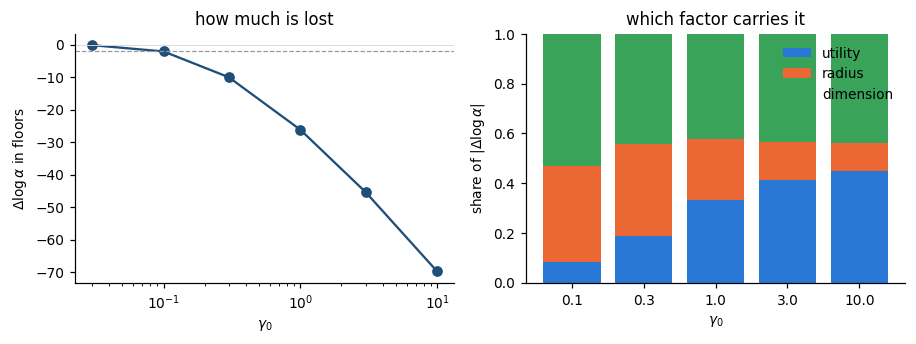

In [9]:
FACTORS = ("utility", "radius", "dimension")
MIN_FLOORS = 2.0
N_UNIQUE = json.loads((REPO / "results/unique_n8.json").read_text())["unique_seeds_per_cell"]


def load_sidecar(pattern):
    hits = sorted((REPO / "figures").glob(pattern))
    if not hits:
        raise FileNotFoundError(pattern)
    return json.loads(hits[-1].read_text())


def shares_from_terms(terms):
    mag = {k: abs(terms[k]) for k in FACTORS}
    total = sum(mag.values())
    return {k: mag[k] / total for k in FACTORS}


def fmt(x, nd=3):
    if x is None:
        return "—"
    return f"{x:.{nd}f}"


fig2 = load_sidecar("fig2_gamma_sweep__forgetting__lag12__*.json")
print("lag 12, task 0, module A, three forgetting corners")
print(f"unique arrangement draws per cell: {N_UNIQUE}")
print()
print(f"{'gamma':>7} {'floors':>8}  {'status':<16} "
      f"{'utility':>8} {'radius':>8} {'dimension':>8}")
rows_f1 = []
for g in sorted(fig2["data"], key=float):
    row = fig2["data"][g]
    fl = row["floors_signed"]
    resolved = abs(fl) >= MIN_FLOORS
    sh = shares_from_terms(row["terms"]) if resolved else None
    status = "resolvable" if resolved else "below floor"
    print(f"{float(g):7g} {fl:8.1f}  {status:<16} "
          f"{fmt(None if sh is None else sh['utility']):>8} "
          f"{fmt(None if sh is None else sh['radius']):>8} "
          f"{fmt(None if sh is None else sh['dimension']):>8}")
    rows_f1.append((float(g), fl, sh, row))

gammas = [g for g, fl, sh, _ in rows_f1]
floors = [fl for _, fl, _, _ in rows_f1]
fig, ax = plt.subplots(1, 2, figsize=(8.4, 3.2))

ax[0].plot(gammas, floors, "o-", color="#1f4e79")
ax[0].axhline(-MIN_FLOORS, color="0.6", ls="--", lw=0.8)
ax[0].axhline(0, color="0.85", lw=0.6)
ax[0].set_xscale("log")
ax[0].set_xlabel("$\\gamma_0$")
ax[0].set_ylabel("$\\Delta \\log \\alpha$ in floors")
ax[0].set_title("how much is lost")

resolved = [(g, sh) for g, fl, sh, _ in rows_f1 if sh is not None]
g_r = [g for g, _ in resolved]
bottom = np.zeros(len(g_r))
colours = {"utility": "#2a78d6", "radius": "#eb6834", "dimension": "#3aa35a"}
for k in FACTORS:
    vals = np.array([sh[k] for _, sh in resolved])
    ax[1].bar([str(g) for g in g_r], vals, bottom=bottom, color=colours[k], label=k)
    bottom += vals
ax[1].set_ylim(0, 1)
ax[1].set_xlabel("$\\gamma_0$")
ax[1].set_ylabel("share of $|\\Delta \\log \\alpha|$")
ax[1].set_title("which factor carries it")
ax[1].legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()


$\gamma_0 = 0.03$ sits at 0.2 floors, below the gate, so the composition is not
read there. From $\gamma_0 = 1$ to $10$ the utility share rises and the radius
share falls. The left panel is how much retained capacity is lost. The right
panel is which geometric factor carries that loss.

An increase in effective radius has two possible sources. Wakhloo, Sussman and
Chung (2023) prove a duality. Correlations between manifold centres act like the
centres being pushed closer together, and correlations between axes act like the
radii shrinking. The radius channel is therefore ambiguous between manifolds
inflating and manifolds approaching one another, unless centre correlation is
reported beside it. We calibrate the conversion on synthetic manifolds and
report the share.

### Finding 2. Retention is a surplus above a general baseline

The registered prediction was that generic capacity would fall as retained
capacity rose, and that their crossing would locate the behavioural optimum.
Generic capacity rises instead, from 0.3043 to 0.3750 across the sweep, a change
of 11.3 floors. The prediction is refuted in sign, and no crossing exists.

The expectation was ill-founded on grounds available beforehand. Feature
learning untangles manifolds (Chou et al. 2025), and generic capacity measures
untangling.

What the numbers show is a widening gap. Both capacities rise, generic by a
factor of 1.23 and retained by 4.4, to 1.3710. Retained capacity exceeds generic
at every $\gamma_0$, including the laziest arm, where the margin is +0.0086.
Task-specific organisation accumulates on top of general organisation rather
than at its expense. Forgetting is the relaxation of that excess toward the
baseline, and it does not arrive.

The claim has content beyond its own terms. If the size of the decay were fixed
by the size of the surplus, the sentence would be circular. Within fixed
$\gamma_0$ the correlation between surplus size and decay size is +0.115, and
negative at low $\gamma_0$. They are separate quantities.

### Finding 3. The stream sets the sign, and the two similarity axes act separately

The four conditions are the $2\times 2$ of feature similarity and readout
similarity. The measured quantity is the change in centre correlation
$\Delta\rho_c$ of the hidden representation, from just after task 0 to lag 12.
That is one scalar per stream. It collapses the trajectory into a net
displacement of the centres. Consecutive-task similarity is held at the
corner's level throughout. Order is the fixed one-pass schedule of §2.

The readout main effect is the mean of the two high-readout corners minus the
mean of the two low-readout corners. The feature main effect is the same
contrast on the feature axis. The interaction is the remaining $2\times 2$
contrast. Readout similarity drives $\Delta\rho_c$ positive (centres converge).
Feature similarity drives it negative (centres decorrelate).


Delta rho_c over the stream, gamma = 10, unique n = 8

corner    feature  readout  Delta rho_c      SEM  declining  sign-test p
S-HH         high     high      +0.0551   0.0078   0/8         0.00781
S-HL         high      low      -0.0550   0.0078   8/8         0.00781
S-LH          low     high      +0.1098   0.0067   0/8         0.00781
S-LL          low      low      +0.0114   0.0060   3/8           0.727

effect                      value status          
readout (main)            +0.1043 drives +rho_c   
feature (main)            -0.0606 drives -rho_c   
interaction               +0.0059 unresolved        (0.82 unique SEM)


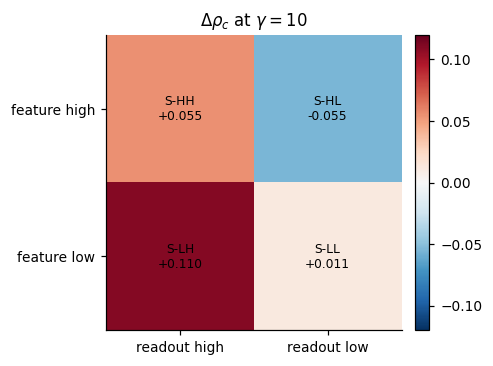

In [10]:
u8 = json.loads((REPO / "results/unique_n8.json").read_text())
cells_f2 = u8["fig4"]["10"]["cells"]
eff = u8["fig4"]["10"]["effects"]
inter_sem = u8["fig4"]["10"]["interaction_sem_unique"]
inter_over = u8["fig4"]["10"]["interaction_over_sem_unique"]
corners = ("S-HH", "S-HL", "S-LH", "S-LL")

print("Delta rho_c over the stream, gamma = 10, unique n =", N_UNIQUE)
print()
print(f"{'corner':<8} {'feature':>8} {'readout':>8} {'Delta rho_c':>12} "
      f"{'SEM':>8} {'declining':>10} {'sign-test p':>12}")
for c in corners:
    feat = "high" if c[2] == "H" else "low"
    read = "high" if c[3] == "H" else "low"
    d = cells_f2[c]
    print(f"{c:<8} {feat:>8} {read:>8} {d['delta_mean']:+12.4f} "
          f"{d['sem_unique']:8.4f} {d['n_declining_unique']:>3}/{d['n_unique']:<4} "
          f"{d['p_unique']:12.3g}")

print()
print(f"{'effect':<22} {'value':>10} {'status':<16}")
print(f"{'readout (main)':<22} {eff['readout']:+10.4f} {'drives +rho_c':<16}")
print(f"{'feature (main)':<22} {eff['feature']:+10.4f} {'drives -rho_c':<16}")
status = "unresolved" if abs(inter_over) < 2 else "resolvable"
print(f"{'interaction':<22} {eff['interaction']:+10.4f} {status:<16}"
      f"  ({inter_over:.2f} unique SEM)")

mat = np.array([
    [cells_f2["S-HH"]["delta_mean"], cells_f2["S-HL"]["delta_mean"]],
    [cells_f2["S-LH"]["delta_mean"], cells_f2["S-LL"]["delta_mean"]],
])
fig, ax = plt.subplots(figsize=(4.2, 3.4))
im = ax.imshow(mat, cmap="RdBu_r", vmin=-0.12, vmax=0.12)
ax.set_xticks([0, 1], ["readout high", "readout low"])
ax.set_yticks([0, 1], ["feature high", "feature low"])
for i, row_cs in enumerate((("S-HH", "S-HL"), ("S-LH", "S-LL"))):
    for j, c in enumerate(row_cs):
        ax.text(j, i, f"{c}\n{cells_f2[c]['delta_mean']:+.3f}",
                ha="center", va="center", color="k", fontsize=8)
ax.set_title("$\\Delta\\rho_c$ at $\\gamma=10$")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


S-HL is the only corner whose mean $\Delta\rho_c$ is negative. The other three
are positive. Those four signs are what the two main effects predict. The
interaction is 0.82 unique SEMs, below the two-SEM gate used for resolvability
everywhere else, so it is not read as a third effect.

### Finding 4. One corner gains

When consecutive tasks are similar in both feature and readout (S-HH), retained
capacity on the earlier task increases as training continues. A later split can
improve the geometry for an earlier question when the two splits share
structure.

**Lag** is the number of task boundaries between learning a split and measuring
it. Lag 12 is twelve tasks later.


lag 12, task 0, module A
unique arrangement draws per cell: 8

  gamma  S-HH floors  S-HH dlog a S-HH status        loss floors  loss dlog a loss status     
   0.03          0.8      +0.0145 below floor               -0.2      -0.0033 below floor     
    0.1          4.5      +0.0836 resolvable                -2.1      -0.0389 resolvable      
    0.3          9.3      +0.1731 resolvable               -10.0      -0.1859 resolvable      
      1         11.8      +0.2194 resolvable               -26.2      -0.4849 resolvable      
      3         10.9      +0.2014 resolvable               -45.3      -0.8400 resolvable      
     10          6.2      +0.1141 resolvable               -69.7      -1.2917 resolvable      

resolvable S-HH cells that gain:              5/5
resolvable three-corner cells that gain:      0/5
Resolvable gains occur in S-HH only.


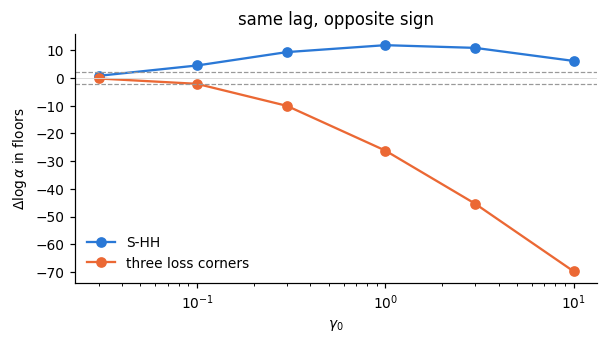

In [11]:
fig2_gain = load_sidecar("fig2_gamma_sweep__S-HH__lag12__*.json")
assert fig2["data"].keys() == fig2_gain["data"].keys()
print("lag 12, task 0, module A")
print(f"unique arrangement draws per cell: {N_UNIQUE}")
print()
print(f"{'gamma':>7} {'S-HH floors':>12} {'S-HH dlog a':>12} {'S-HH status':<16}  "
      f"{'loss floors':>12} {'loss dlog a':>12} {'loss status':<16}")
n_gain = n_loss_gain = 0
n_gain_resolved = n_loss_resolved = 0
for g in sorted(set(fig2["data"]) | set(fig2_gain["data"]), key=float):
    loss = fig2["data"][g]
    gain = fig2_gain["data"][g]
    loss_ok = abs(loss["floors_signed"]) >= MIN_FLOORS
    gain_ok = abs(gain["floors_signed"]) >= MIN_FLOORS
    loss_st = "resolvable" if loss_ok else "below floor"
    gain_st = "resolvable" if gain_ok else "below floor"
    print(f"{float(g):7g} {gain['floors_signed']:12.1f} {gain['dlog_alpha']:+12.4f} {gain_st:<16}  "
          f"{loss['floors_signed']:12.1f} {loss['dlog_alpha']:+12.4f} {loss_st:<16}")
    if gain_ok:
        n_gain_resolved += 1
        if gain["dlog_alpha"] > 0:
            n_gain += 1
    if loss_ok:
        n_loss_resolved += 1
        if loss["dlog_alpha"] > 0:
            n_loss_gain += 1

print()
print(f"resolvable S-HH cells that gain:              {n_gain}/{n_gain_resolved}")
print(f"resolvable three-corner cells that gain:      {n_loss_gain}/{n_loss_resolved}")
print("Resolvable gains occur in S-HH only.")

keys = sorted(fig2["data"], key=float)
g_all = [float(k) for k in keys]
fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.plot(g_all, [fig2_gain["data"][k]["floors_signed"] for k in keys],
        "o-", color="#2a78d6", label="S-HH")
ax.plot(g_all, [fig2["data"][k]["floors_signed"] for k in keys],
        "o-", color="#eb6834", label="three loss corners")
ax.axhline(MIN_FLOORS, color="0.6", ls="--", lw=0.8)
ax.axhline(-MIN_FLOORS, color="0.6", ls="--", lw=0.8)
ax.axhline(0, color="0.85", lw=0.6)
ax.set_xscale("log")
ax.set_xlabel("$\\gamma_0$")
ax.set_ylabel("$\\Delta \\log \\alpha$ in floors")
ax.set_title("same lag, opposite sign")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


Resolvable gains occur in S-HH only. The three loss corners stay negative
wherever they clear the floor.

Overwriting can only subtract. A corner that gains therefore separates two
accounts of what forgetting is. If an earlier task's arrangement had been
written over, later training could not restore it. If what was lost is the fit
between a geometry and one particular question, then material sharing that
question's structure can improve the fit.

The gain is specific to one corner. Of 520 conditions examined across the grid,
the width arms and the $\gamma_0 = 30$ probe, 172 have a positive mean and 98
clear two floors. All 98 are S-HH. The largest positive mean anywhere else
reaches 0.74 floors, a third of the gate.

S-HH is high on both similarity axes. Hiratani (2024) predicts that combination
is comparatively benign for retention. The geometry here goes past benign.

Taken together, the four findings describe retention as a match between
geometry and a particular question. Generic capacity is what a typical new
question would still get. A past split can sit above that, lose some of the
match, and regain it when later splits share its structure. Finding 1 is the
loss and its composition. Finding 2 is the surplus above that baseline.
Finding 3 is which stream property sets the sign of the centre motion.
Finding 4 is the regain.


## 9. What this is allowed to mean

A number here is licensed for this network, this optimiser, this synthetic
stream, and this estimator. Four constraints follow from that.

**Content was never scarce.** Sixteen random centres in 150 dimensions under one
ReLU are nearly separable before any training. The network is not learning to
represent the categories. It is rearranging an adequate representation to
separate them more efficiently, which is what the utility factor measures.
Finding 1 was obtained in the only setting where representational content was
never at stake. Depth is the variable that would change that, and depth is
fixed in the numbers above.

**Training length was equalised by loss, not by amount of change.** Reaching the
same error takes thousands of steps at small $\gamma_0$ and tens at large
$\gamma_0$. "The lazy network's geometry barely moves" cannot be cleanly
separated from "reaching this error does not require moving it."

**Everything is about linear readability.** A representation that scrambled a
task nonlinearly while preserving its information would register as complete
forgetting.

**The design sits at one extreme of its own space.** Holding inputs fixed and
changing only the rule is the configuration predicted to be most damaging.
Chosen on purpose, and not typical.

Ranked by exposure to all of this, the stream-sets-the-sign result is most
robust (the network is a constant, so it cannot generate the $2\times 2$).
Retention-as-surplus is middling. The channel composition is most exposed,
since which channel can move depends on depth and on the near-separability
above.


## 10. Where it goes

Six controls have been measured, each at unique $n = 8$.

**Rank at fixed $\gamma_0$.** A nested low-rank bottleneck on the readout path,
so the measured representation keeps its ambient dimension while its
task-relevant dimension is constrained. The utility-share reorganisation with
$\gamma_0$ survives it: the $\gamma_0 = 1 \to 10$ step is 0.110 at $r=4$ against
0.106 at full rank. This is the control that
$\gamma_0$'s co-variation with optimisation dynamics asks for.

**Isotropic-Gaussian manifolds.** The App. D.1.1 variant without unit-norm
spherical shells, so the intrinsic dimension parameter is absent by
construction. The share step at $\gamma_0 = 1 \to 10$ reproduces (0.149 against
0.106 on spherical $r=N$). Absolute levels sit lower.

**Held-out arrangements.** The three-corner headline reproduces on a reserved
set that informed no design decision (69.2 floors at $\gamma_0 = 10$, against
69.7 floors on the design set).

**Scope.** The same dichotomy sequence, cut at three output granularities.
Forgetting differs by partition (0.448, 0.420, 0.375 at $K = 1, 2, 4$,
$\gamma_0 = 10$, three-corner utility share). One stream, three
observer cuts, three answers.

**Corrected learning rate.** Atanasov et al. (2025) give
$\eta^* \propto \gamma^{2/L}$ in the rich regime, against the quadratic law used
here; at $L = 2$ the two differ by a factor of $\gamma$. Composition is unchanged
above $\gamma_0 = 1$. The utility share moves by 0.020 against a 0.58 term, where
the sweep's own share step is 0.12. Quadratic remains primary.

**Recurrence.** Re-presenting task 0 at position 12 costs the same as learning a
novel dichotomy matched on similarity to its predecessor. The paired difference
in steps to target is +0.94 ± 0.69 at $\gamma_0 = 10$ and +4.63 ± 3.65 at
$\gamma_0 = 1$, neither excluding zero. The geometric surplus is not
behaviourally recoverable, so the geometric and behavioural pictures diverge.
Only the low-readout-similarity corners are testable: at $P = 16$, re-presenting
task 0 is incompatible with holding readout similarity high, which is a
constraint on the design space rather than on the runs.

Still open, in this order.

**Depth.** One extra hidden layer, blocked on a signed $\mu$P specification at
$L = 3$. This is the test of whether the utility channel dominates only because
representational content was never scarce. The recurrence null sharpens it: if
the surplus is legible to a linear readout and not to the optimiser, whether
that holds when features must be built rather than rearranged is the next
question.

**Continual-learning baselines.** Not as a comparison. EWC constrains directions
and replay re-presents distributions, so the decomposition can report which
channel each protects.

**One naturalistic arm**, scoped as a lower bound.

If the scarcity argument can be stated as a prediction rather than a
retrospective constraint, the depth experiment becomes a test of a mechanism
instead of an interpretation of a result.
